In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score

sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
from funcs import *
from processing_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_130126/No_plates/30cm/finding_volt_to_meter_30cm/')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Wave analysis
**The measurements were conducted January 2026 by Kjersti Stangeland.**

**This notebook analyzes wave gauge measurements of parameters:**

*Wave maker settings*
* 1.306 Hz frequency
* 0.25 V amplitude
* 0.3 m water depth
* 60*frequency periods ran
* 60 second trigger
* NO PLATES, empty tank

*Probe placements*
* $P_0$: 4.86 meters after paddle
* $P_1$: 6.69 meters after paddle
* $P_2$: 7.87 meters after paddle
* $P_3$: 9.15 meters after paddle

*The plates will be placed between 6.34 m - 9.38 m.*

In [8]:
# Change parameters here

base_path = '/Users/kjesta/Desktop/LABDATA/Kjersti_130126/No_plates/30cm/finding_volt_to_meter_30cm/f1306/a025'

filename = '30cm_f1306_a025'

# For plotting
freq = 1.306 # in Hz
amp = 0.25 # in voltage
depth = 0.30 # in meters

# File name for output txt file
output_path = os.path.join(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/30cm/volt_to_meter_runs/', '30cm_f1306_a025_wave_parameters.txt')
# Paths to raw data files
r1_path = os.path.join(base_path, 'f1306a025h03r1.csv')
r2_path = os.path.join(base_path, 'f1306a025h03r2.csv')
r3_path = os.path.join(base_path, 'f1306a025h03r3.csv')

In [9]:
r1_raw = pd.read_csv(r1_path)
r2_raw = pd.read_csv(r2_path)
r3_raw = pd.read_csv(r3_path)

headers = ['time', 'P_0', 'P_1', 'P_2', 'P_3', 'sound_speed']

r1_raw.columns = headers
r2_raw.columns = headers
r3_raw.columns = headers

# Post processing steps:

# 1) Remove noise (probe artefacts) and convert time to seconds
r1_clean = clean(r1_raw)
r2_clean = clean(r2_raw)
r3_clean = clean(r3_raw)

# 2) Detrend data, set mean water level to zero
r1_detrended = detrend(r1_clean)
r2_detrended = detrend(r2_clean)
r3_detrended = detrend(r3_clean)

# Checking that all probes now have zero mean (still water level)
for col in ['P_0', 'P_1', 'P_2', 'P_3']:
    print(np.mean(r1_detrended[col]), np.mean(r2_detrended[col]), np.mean(r3_detrended[col]))

1.3731588949724399e-18 1.5653101107140899e-18 -1.5210055437364645e-18
-1.5804281621380912e-18 1.369183784785374e-18 1.3988810110276973e-18
-1.643349189670521e-18 1.6282185548799043e-18 6.069219201284189e-19
-1.3620551842314229e-18 -6.808913956770509e-19 1.4802973661668755e-18


In [10]:
r1 = r1_detrended
r2 = r2_detrended
r3 = r3_detrended

In [11]:
# Positions of probes
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])  # Base positions, meters from wave maker

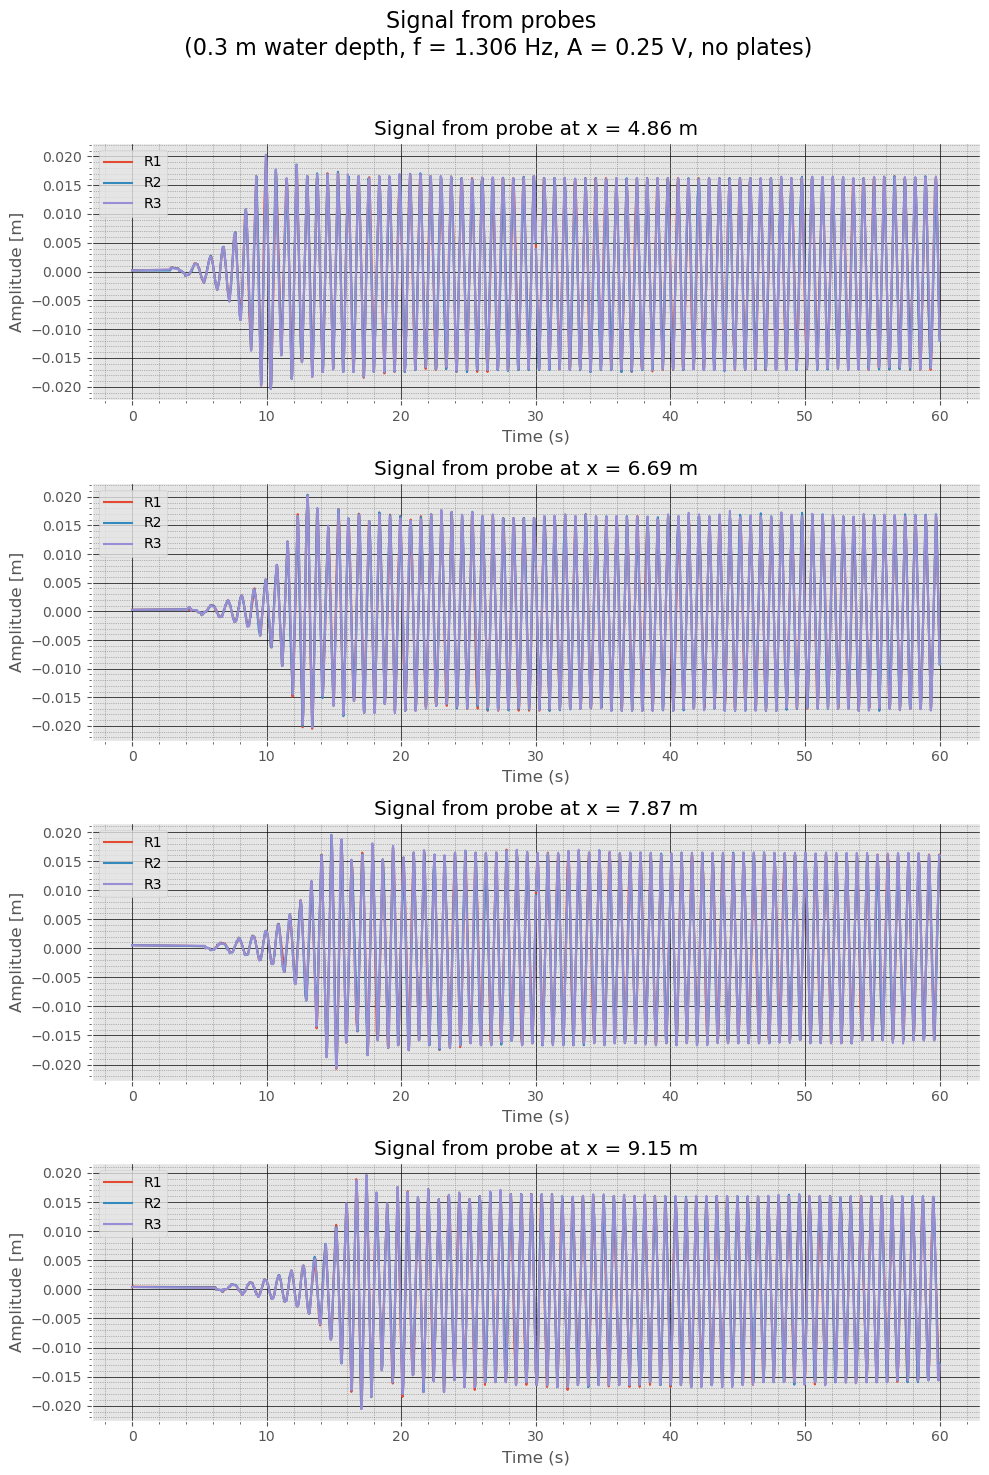

In [12]:
fig, ax = plt.subplots(4,1, figsize=(10, 15))

# P0
ax[0].plot(r1['time'], r1['P_0'], label='R1')
ax[0].plot(r2['time'], r2['P_0'], label='R2')
ax[0].plot(r3['time'], r3['P_0'], label='R3')

# P1
ax[1].plot(r1['time'], r1['P_1'], label='R1')
ax[1].plot(r2['time'], r2['P_1'], label='R2')
ax[1].plot(r3['time'], r3['P_1'], label='R3')

# P2
ax[2].plot(r1['time'], r1['P_2'], label='R1')
ax[2].plot(r2['time'], r2['P_2'], label='R2')
ax[2].plot(r3['time'], r3['P_2'], label='R3')

# P3
ax[3].plot(r1['time'], r1['P_3'], label='R1')
ax[3].plot(r2['time'], r2['P_3'], label='R2')
ax[3].plot(r3['time'], r3['P_3'], label='R3')

for axs in ax:
    axs.grid(which='major', linestyle='-', linewidth='0.5', color='black')
    axs.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    axs.legend()
    axs.set_xlabel('Time (s)')
    axs.set_ylabel('Amplitude [m]')
    axs.minorticks_on()

fig.suptitle(f'Signal from probes \n ({depth} m water depth, f = {freq} Hz, A = {amp} V, no plates)', fontsize=16)
ax[0].set_title(f'Signal from probe at x = {x_probe_pos[0]} m')
ax[1].set_title(f'Signal from probe at x = {x_probe_pos[1]} m')
ax[2].set_title(f'Signal from probe at x = {x_probe_pos[2]} m')
ax[3].set_title(f'Signal from probe at x = {x_probe_pos[3]} m')
plt.tight_layout(rect=[0, 0, 1, 0.96])

The wave maker takes some time to build a steady wave train. I therefore cut off the beginning of the time series, based on what I visually intepret as the steady wave train.

In [13]:
# Time of first front arrival at P0
wave_maker_build_up_time =  14 # seconds

In [14]:
r1_valid = cut_out_valid_data(r1, freq, depth, wave_maker_build_up_time, x_probe_pos)
r2_valid = cut_out_valid_data(r2, freq, depth, wave_maker_build_up_time, x_probe_pos)
r3_valid = cut_out_valid_data(r3, freq, depth, wave_maker_build_up_time, x_probe_pos)

----- Cutting out invalid data -----
Time after transient front reaches each probe: [14.         19.27160494 22.67078189 26.35802469]

Reflection arrival times at each probe: [61.8005763  56.18513168 52.5642439  48.63650121]

Time window between build-up and reflection at each probe: [47.8005763  36.91352674 29.893462   22.27847652]

Maximum number of usable wave periods at each probe: [62.42755265 48.20906593 39.04086137 29.09569033]
-------------------------------------------------
----- Cutting out invalid data -----
Time after transient front reaches each probe: [14.         19.27160494 22.67078189 26.35802469]

Reflection arrival times at each probe: [61.8005763  56.18513168 52.5642439  48.63650121]

Time window between build-up and reflection at each probe: [47.8005763  36.91352674 29.893462   22.27847652]

Maximum number of usable wave periods at each probe: [62.42755265 48.20906593 39.04086137 29.09569033]
-------------------------------------------------
----- Cutting out inva

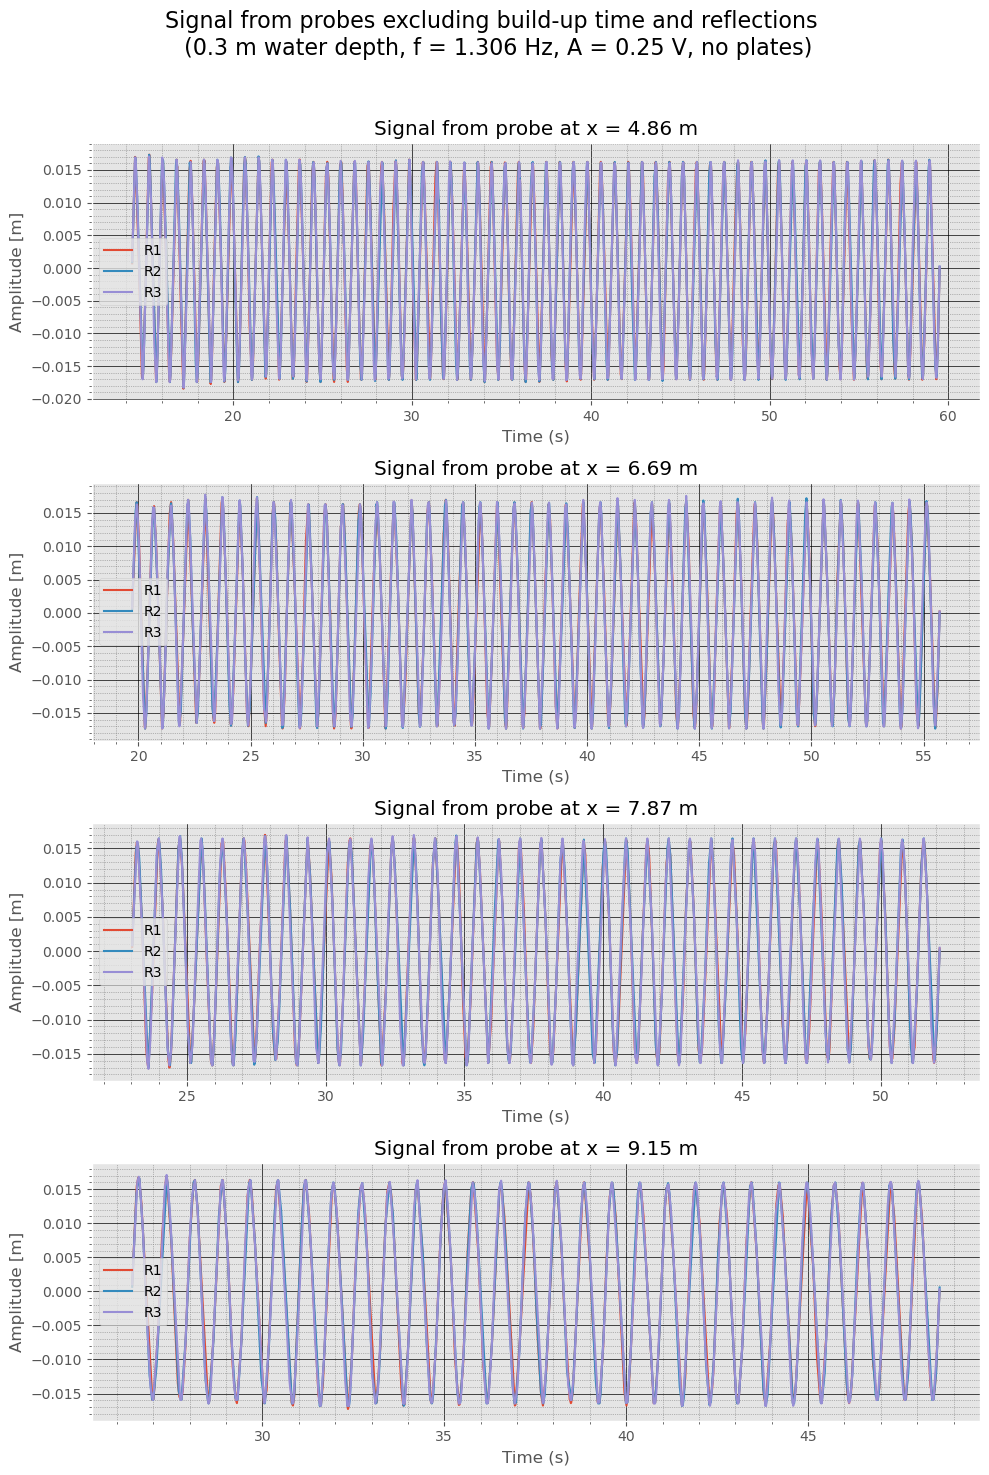

In [15]:
fig, ax = plt.subplots(4,1, figsize=(10, 15))

# P0
ax[0].plot(r1_valid['time'], r1_valid['P_0'], label='R1')
ax[0].plot(r2_valid['time'], r2_valid['P_0'], label='R2')
ax[0].plot(r3_valid['time'], r3_valid['P_0'], label='R3')

# P1
ax[1].plot(r1_valid['time'], r1_valid['P_1'], label='R1')
ax[1].plot(r2_valid['time'], r2_valid['P_1'], label='R2')
ax[1].plot(r3_valid['time'], r3_valid['P_1'], label='R3')

# P2
ax[2].plot(r1_valid['time'], r1_valid['P_2'], label='R1')
ax[2].plot(r2_valid['time'], r2_valid['P_2'], label='R2')
ax[2].plot(r3_valid['time'], r3_valid['P_2'], label='R3')

# P3
ax[3].plot(r1_valid['time'], r1_valid['P_3'], label='R1')
ax[3].plot(r2_valid['time'], r2_valid['P_3'], label='R2')
ax[3].plot(r3_valid['time'], r3_valid['P_3'], label='R3')

for axs in ax:
    axs.grid(which='major', linestyle='-', linewidth='0.5', color='black')
    axs.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    axs.legend()
    axs.set_xlabel('Time (s)')
    axs.set_ylabel('Amplitude [m]')
    axs.minorticks_on()

fig.suptitle(f'Signal from probes excluding build-up time and reflections \n ({depth} m water depth, f = {freq} Hz, A = {amp} V, no plates)', fontsize=16)
ax[0].set_title(f'Signal from probe at x = {x_probe_pos[0]} m')
ax[1].set_title(f'Signal from probe at x = {x_probe_pos[1]} m')
ax[2].set_title(f'Signal from probe at x = {x_probe_pos[2]} m')
ax[3].set_title(f'Signal from probe at x = {x_probe_pos[3]} m')
plt.tight_layout(rect=[0, 0, 1, 0.96])

With the mean of the signal being zero, the standard deviation of it is proportional to the wave amplitude. 

$\eta(t) = Asin(\omega t)$, $\bar{\eta} = 0$.

$\sigma = \sqrt{\frac{1}{T}\int_0^T \eta(t)^2 dt}$, $\sigma = \sqrt{\frac{1}{T}\int_0^T Asin^2(\omega t) dt}$, 

$\sigma = \sqrt{\frac{1}{T}\int_0^T A(\frac{1 + cos(2\omega t)}{2}) dt}$, 

$\sigma = A\sqrt{\frac{1}{2}(1 - \frac{1}{T}\int_0^T cos(2\omega t))} dt$.

We know that the average of the cosine term over a full period is zero, so:

$\frac{1}{T}\int_0^T cos(2\omega t) dt = 0$  meaning, $\frac{1}{T}\int_0^T sin^2(\omega t) dt = \frac{1}{2}$, 

$\sigma = \frac{A}{\sqrt(2)}$ and:

$A = \sqrt{2}\sigma$.

In [16]:
# Standard deviation for each probe and run
std_P0_r1 = np.std(r1_valid['P_0'])
std_P0_r2 = np.std(r2_valid['P_0'])
std_P0_r3 = np.std(r3_valid['P_0'])

std_P1_r1 = np.std(r1_valid['P_1'])
std_P1_r2 = np.std(r2_valid['P_1'])
std_P1_r3 = np.std(r3_valid['P_1'])

std_P2_r1 = np.std(r1_valid['P_2'])
std_P2_r2 = np.std(r2_valid['P_2'])
std_P2_r3 = np.std(r3_valid['P_2'])

std_P3_r1 = np.std(r1_valid['P_3'])
std_P3_r2 = np.std(r2_valid['P_3'])
std_P3_r3 = np.std(r3_valid['P_3'])

# Taking the mean std for each probe across runs and calculating amplitude
amp_P0 = np.sqrt(2) * np.mean([std_P0_r1, std_P0_r2, std_P0_r3])
amp_P1 = np.sqrt(2) * np.mean([std_P1_r1, std_P1_r2, std_P1_r3])
amp_P2 = np.sqrt(2) * np.mean([std_P2_r1, std_P2_r2, std_P2_r3])
amp_P3 = np.sqrt(2) * np.mean([std_P3_r1, std_P3_r2, std_P3_r3])

amps = np.array([amp_P0, amp_P1, amp_P2, amp_P3])

# Standard error
errors = []

errors.append(np.mean([std_P0_r1, std_P0_r2, std_P0_r3]) / np.sqrt(len(r1_valid['P_0'])))
errors.append(np.mean([std_P1_r1, std_P1_r2, std_P1_r3]) / np.sqrt(len(r1_valid['P_1'])))
errors.append(np.mean([std_P2_r1, std_P2_r2, std_P2_r3]) / np.sqrt(len(r1_valid['P_2'])))
errors.append(np.mean([std_P3_r1, std_P3_r2, std_P3_r3]) / np.sqrt(len(r1_valid['P_3'])))

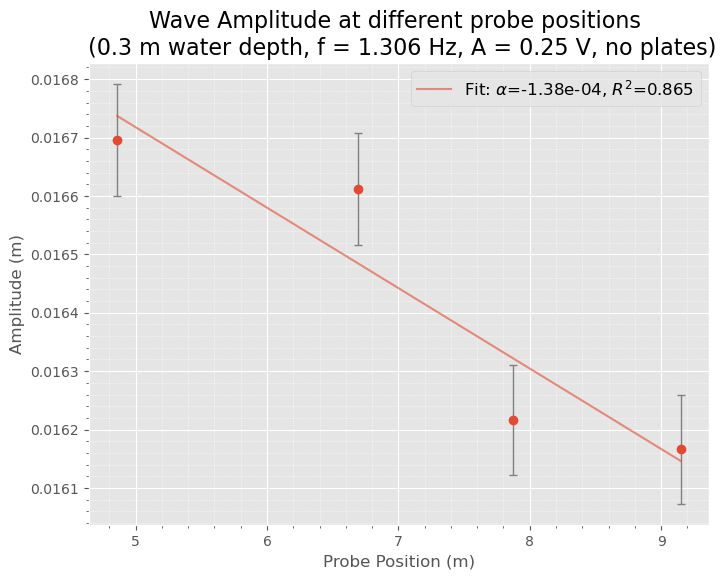

In [17]:
# Linear regression of amplitude vs probe position
coeff = np.polyfit(x_probe_pos, amps, 1)  
line = np.poly1d(coeff)           
    
r2 = r2_score(amps, line(x_probe_pos))

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(x_probe_pos,
            amps,
            yerr=errors,
            fmt='o',
            ecolor='grey',
            elinewidth=1,
            capsize=3)

xx = np.linspace(min(x_probe_pos), max(x_probe_pos), 200)
ax.plot(xx, line(xx), color= 'C0', alpha=0.6,
         label=rf'Fit: $\alpha$={coeff[0]:.2e}, $R^2$={r2:.3f}')

ax.grid(which='minor', linestyle=':', linewidth='0.5', color='white')
ax.minorticks_on()

ax.set_xlabel('Probe Position (m)', fontsize=12)
ax.set_ylabel('Amplitude (m)', fontsize=12)
ax.set_title(f'Wave Amplitude at different probe positions \n ({depth} m water depth, f = {freq} Hz, A = {amp} V, no plates)', fontsize=16)
ax.legend(fontsize=12)

#fig.savefig(os.path.join(figpath, f'{filename}_amplitude.png'), dpi=400)

In [18]:
"""
Estimating wavelength from frequency using linear wave theory.
The estimate_wavenumber function is defined in funcs.py
and uses Newton-Raphson iterative method to solve the dispersion relation.
"""
k = estimate_wavenumber(freq, depth)

# From wavenumber to wavelength
wl = 2 * np.pi / k

In [19]:
"""
Estimating phase speed and group speed using linear wave theory.
The phase speed c and group speed cg are calculated using the formulas:
(Kundu et al., Fluid Mechanics, 6th edition, p. 372).
c = omega / k
cg = (c / 2) * (1 + (2 * k * depth) / (sinh(2 * k * depth)))
where omega = 2 * pi * frequency
"""
c = 2 * np.pi * freq / k
cg = (c / 2) * (1 + (2 * k * depth) / (np.sinh(2 * k * depth)))

In [20]:
# Amplitude decay rate
dx = x_probe_pos[-1] - x_probe_pos[0]
da = amp_P0 - amp_P3
alpha = da / dx 

In [21]:
# Dimensionless parameters
kH = k * depth
ak = (amp_P0 * k)

## Summary of wave parameters

In [22]:
# Write to file
with open(output_path, 'w') as f:
    f.write(f'Summary of wave parameters for {filename}:\n')
    f.write('----------------------------------------------------------\n')
    f.write(f'Water depth: {depth} m, Frequency: {freq} Hz, Amplitude setting: {amp} V\n\n')
    f.write(f'Wavelength: {wl:.4f} m\n')
    f.write(f'Wavenumber: {k:.4f} 1/m\n')
    f.write(f'Phase speed: {c:.4f} m/s\n')
    f.write(f'Group speed: {cg:.4f} m/s\n\n')
    f.write('Dimensionless parameters:\n')
    f.write(f'ak = {ak:.4f}, kH = {kH:.4f}\n\n')
    f.write('Standard Deviation for each probe:\n')
    f.write(f'P0: {np.mean([std_P0_r1, std_P0_r2, std_P0_r3]):.4f} m\n')
    f.write(f'P1: {np.mean([std_P1_r1, std_P1_r2, std_P1_r3]):.4f} m\n')
    f.write(f'P2: {np.mean([std_P2_r1, std_P2_r2, std_P2_r3]):.4f} m\n')
    f.write(f'P3: {np.mean([std_P3_r1, std_P3_r2, std_P3_r3]):.4f} m\n\n')
    f.write(f'Wave Amplitude for each probe:\n')
    f.write(f'P0: {amp_P0:.4f} m\n')
    f.write(f'P1: {amp_P1:.4f} m\n')
    f.write(f'P2: {amp_P2:.4f} m\n')
    f.write(f'P3: {amp_P3:.4f} m\n\n')
    f.write(f'Amplitude Difference between P0 and P3: {amp_P0 - amp_P3:.5f} m, R^2 = {r2:.3f}\n')
    f.write(f'Spatial Amplitude Decay Rate: {alpha:.5f} m/m\n\n')
    f.write('Number of data points used for analysis after cutting out build-up time and reflections:\n')
    f.write('Run 1:\n')
    for probe in ['P_0', 'P_1', 'P_2', 'P_3']:
        f.write(f'{probe}: {r1_valid[probe].notna().sum()} data points\n')
    f.write('Run 2:\n')
    for probe in ['P_0', 'P_1', 'P_2', 'P_3']:
        f.write(f'{probe}: {r2_valid[probe].notna().sum()} data points\n')
    f.write('Run 3:\n')
    for probe in ['P_0', 'P_1', 'P_2', 'P_3']:
        f.write(f'{probe}: {r3_valid[probe].notna().sum()} data points\n')
    f.write('\n')  
    f.write('Standard Error of the Mean for each probe:\n')
    f.write(f'P0: {errors[0]*1000:.3f} mm\n')
    f.write(f'P1: {errors[1]*1000:.3f} mm\n')
    f.write(f'P2: {errors[2]*1000:.3f} mm\n')
    f.write(f'P3: {errors[3]*1000:.3f} mm\n')